In [2]:
import pandas as pd                      # serve per leggere e manipolare il dataset pulito
import numpy as np                       # serve per alcuni calcoli numerici
import matplotlib.pyplot as plt          # serve per creare grafici
import seaborn as sns
from scipy import stats                  # serve per eseguire il test d'ipotesi
from sklearn.model_selection import train_test_split   # serve per dividere i dati in train e test
from sklearn.linear_model import LinearRegression      # modello di regressione lineare
from sklearn.metrics import mean_absolute_error, r2_score  # metriche per valutare il modello

pd.set_option("display.max_columns", None)   # fa vedere tutte le colonne quando stampiamo il dataframe

In [5]:
df = pd.read_csv("df_cleaned_chocolate.csv")   # carica il dataframe già pulito e preparato

print("Dimensione del dataframe finale:")
print(df.shape)

Dimensione del dataframe finale:
(990236, 27)


In [6]:
print(df)

           order_id  order_date product_id store_id customer_id  quantity  \
0       0RD00000001  2023-01-07      P0080     S093     C040749         5   
1       0RD00000002  2023-10-22      P0173     S065     C020161         3   
2       0RD00000003  2023-05-07      P0115     S078     C048069         2   
3       0RD00000004  2024-06-23      P0186     S088     C047901         2   
4       0RD00000005  2024-09-24      P0197     S054     C033950         1   
...             ...         ...        ...      ...         ...       ...   
990231  0RD00999996  2023-04-15      P0103     S053     C044763         4   
990232  0RD00999997  2023-05-26      P0094     S058     C004441         2   
990233  0RD00999998  2023-07-05      P0097     S041     C044879         3   
990234  0RD00999999  2024-01-03      P0090     S083     C042525         1   
990235  0RD01000000  2024-04-10      P0175     S090     C025078         1   

        unit_price  discount  revenue  total_cost  profit  \
0            1

In [7]:
# Analisi descrittiva delle variabili numeriche principali
statistiche = df[['quantity', 'unit_price', 'discount', 'revenue', 'profit']].describe()
print(statistiche)

            quantity     unit_price       discount        revenue  \
count  990236.000000  990236.000000  990236.000000  990236.000000   
mean        2.999760       9.002360       0.056242      25.487508   
std         1.413644       3.462932       0.076806      16.369318   
min         1.000000       3.000000       0.000000       2.400000   
25%         2.000000       6.000000       0.000000      12.160000   
50%         3.000000       9.000000       0.000000      21.920000   
75%         4.000000      12.000000       0.150000      35.880000   
max         5.000000      15.000000       0.200000      75.000000   

              profit  
count  990236.000000  
mean       10.195198  
std         6.779464  
min         0.730000  
25%         4.780000  
50%         8.610000  
75%        14.170000  
max        37.430000  


In [8]:
# Raggruppiamo per nome prodotto e calcoliamo la media del profitto
analisi_prodotti = df.groupby('product_name')['profit'].mean().sort_values()

print(analisi_prodotti)

product_name
Truffle Chocolate 90%    10.136759
Dark Chocolate 90%       10.147903
White Chocolate 70%      10.151067
Truffle Chocolate 50%    10.161861
Praline Chocolate 70%    10.163253
Praline Chocolate 80%    10.164487
White Chocolate 60%      10.167646
Praline Chocolate 60%    10.178478
Milk Chocolate 90%       10.179739
Milk Chocolate 80%       10.181377
White Chocolate 90%      10.181986
Truffle Chocolate 80%    10.183944
Dark Chocolate 50%       10.193801
White Chocolate 50%      10.195871
Truffle Chocolate 70%    10.199805
Truffle Chocolate 60%    10.206065
White Chocolate 80%      10.208204
Dark Chocolate 60%       10.217353
Praline Chocolate 90%    10.218348
Milk Chocolate 70%       10.227383
Milk Chocolate 50%       10.231508
Praline Chocolate 50%    10.232512
Dark Chocolate 80%       10.236598
Dark Chocolate 70%       10.245322
Milk Chocolate 60%       10.252003
Name: profit, dtype: float64


In [9]:
# Creiamo due gruppi di dati
dark_70 = df[df['product_name'] == 'Dark Chocolate 70%']['profit']
milk_90 = df[df['product_name'] == 'Milk Chocolate 90%']['profit']

# Eseguiamo il T-Test
t_stat, p_val = stats.ttest_ind(dark_70, milk_90)

print(f"P-Value: {p_val}")

P-Value: 0.20894885854294298


In [10]:
# Calcolo per profitto medio per negozio
analisi_store = df.groupby('store_id')['profit'].mean().sort_values()
print(analisi_store)

store_id
S015     9.969981
S086    10.049232
S055    10.061435
S014    10.093477
S018    10.112034
          ...    
S051    10.302174
S029    10.318859
S074    10.322284
S012    10.344537
S096    10.346868
Name: profit, Length: 100, dtype: float64


In [11]:
# Estraiamo il mese dalla data e calcoliamo il profitto medio
df['month'] = pd.to_datetime(df['order_date']).dt.month
analisi_mese = df.groupby('month')['profit'].mean()

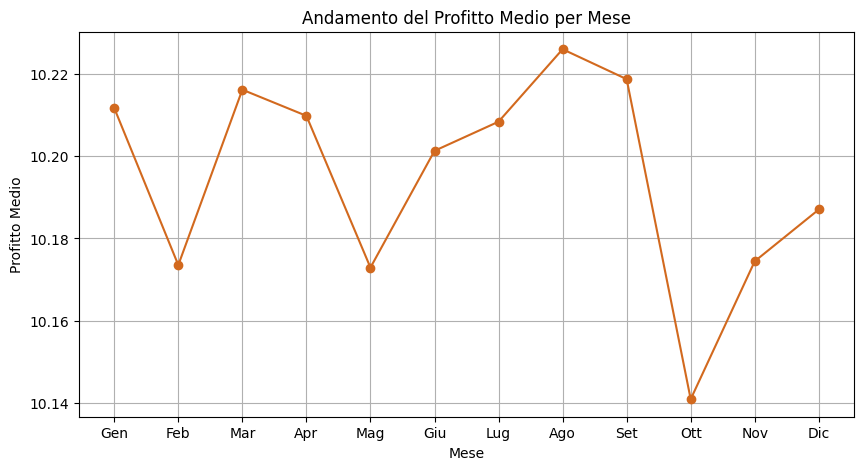

In [12]:
# trend nel tempo
plt.figure(figsize=(10, 5))
analisi_mese.plot(kind='line', marker='o', color='chocolate')
nomi_mesi = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']
plt.xticks(range(1, 13), nomi_mesi)
plt.title('Andamento del Profitto Medio per Mese')
plt.xlabel('Mese')
plt.ylabel('Profitto Medio')
plt.grid(True)
plt.show()

In [13]:
# Creiamo una tabella che conta quanti prodotti per ogni genere
confronto = pd.crosstab(df['gender'], df['product_name'], normalize='index') * 100
print(confronto)

product_name  Dark Chocolate 50%  Dark Chocolate 60%  Dark Chocolate 70%  \
gender                                                                     
Female                  7.000065            5.066174            3.976986   
Male                    7.061705            4.995274            4.042354   

product_name  Dark Chocolate 80%  Dark Chocolate 90%  Milk Chocolate 50%  \
gender                                                                     
Female                  2.516584            4.036885            4.019771   
Male                    2.492131            3.994498            3.993096   

product_name  Milk Chocolate 60%  Milk Chocolate 70%  Milk Chocolate 80%  \
gender                                                                     
Female                  3.496977            5.487303            2.978257   
Male                    3.467278            5.445204            3.004533   

product_name  Milk Chocolate 90%  Praline Chocolate 50%  \
gender                    

In [14]:
correlazione_eta = df['age'].corr(df['profit'])
print(f"Correlazione Età/Profitto: {correlazione_eta}")

Correlazione Età/Profitto: -0.00035477680487285354


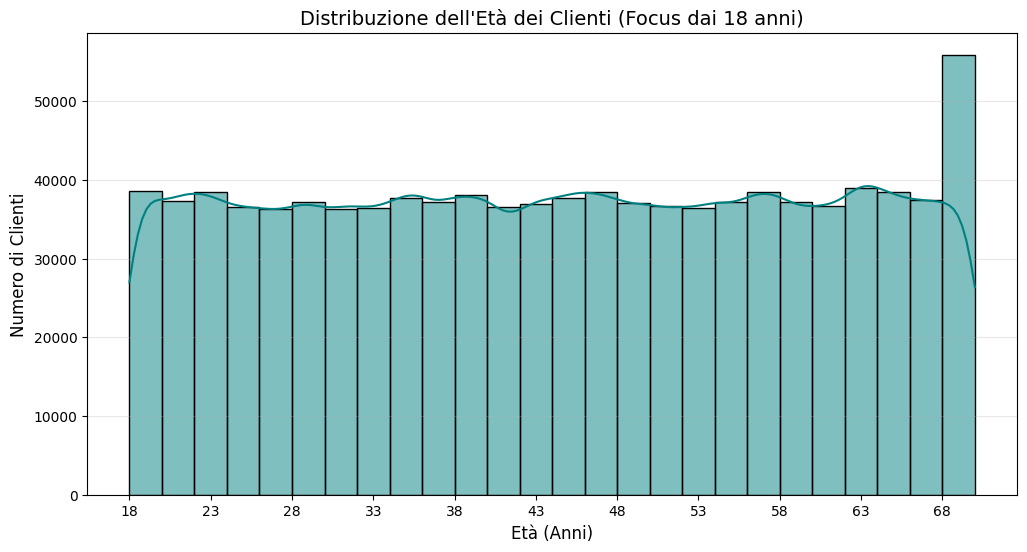

In [15]:
# Creiamo l'istogramma dell'età
plt.figure(figsize=(12, 6))
# Usiamo 'binrange' per dire a Python: "Inizia esattamente a 18 e finisci al massimo"
sns.histplot(df['age'], kde=True, color='teal', binwidth=2, binrange=(18, df['age'].max()))
# Aggiungiamo un segno sull'asse X proprio sul 18
plt.xticks(range(18, int(df['age'].max()) + 1, 5))
plt.title('Distribuzione dell\'Età dei Clienti (Focus dai 18 anni)', fontsize=14)
plt.xlabel('Età (Anni)', fontsize=12)
plt.ylabel('Numero di Clienti', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()